In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)

from config.settings import *

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from google.oauth2 import service_account
from google.cloud import bigquery

creds = service_account.Credentials.from_service_account_file(KEY_PATH)

bq_client = bigquery.Client(
    credentials=creds,
    project=GCP_PROJECT
)

print("Ready for PCA modelling")

/opt/anaconda3/envs/envhealth/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.18) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Ready for PCA modelling


In [2]:
query = f"""
SELECT *
FROM `{BQ_TABLE_MAIN}`
"""

df = bq_client.query(query).to_dataframe()

print(df.shape)
df.head()

(33, 15)


,borough_name,no2_baseline_mean,no2_imputed,no2_source_borough,lden_mean,green_area_m2,imd_score_mean,imd_rank_mean,imd_decile_mean,pct_most_deprived,borough_area_m2_x,green_space_share_pct,borough_area_m2_y,borough_area_m2,major_road_density_km_per_km2
0,Bexley,26.685649,False,Bexley,63.082413,8.659319e+06,15.882363,19696.109589,6.506849,0.0,6.058023e+07,14.293968,6.058023e+07,6.058023e+07,1.434887
1,Camden,53.645008,False,Camden,64.701372,6.431268e+06,19.981053,16247.744361,5.406015,0.0,2.178930e+07,29.515721,2.178930e+07,2.178930e+07,2.996332
2,City of London,59.732950,False,City of London,64.333843,5.145284e+04,14.805000,20275.166667,6.666667,0.0,2.903926e+06,1.771837,2.903926e+06,2.903926e+06,5.195344
3,Harrow,30.330853,False,Harrow,63.580240,6.029958e+06,14.860883,19977.000000,6.554745,0.0,5.046330e+07,11.949195,5.046330e+07,5.046330e+07,1.070482
4,Hillingdon,37.919454,False,Hillingdon,61.948496,1.246287e+07,17.839329,17705.385093,5.906832,0.0,1.157005e+08,10.771660,1.157005e+08,1.157005e+08,1.053197


In [3]:
pca_cols = [
    "no2_baseline_mean",
    "lden_mean",
    "major_road_density_km_per_km2",
    "green_space_share_pct"
]

df[pca_cols].describe().round(2)

,no2_baseline_mean,lden_mean,major_road_density_km_per_km2,green_space_share_pct
count,33.00,33.00,33.00,33.00
mean,38.96,63.69,2.13,21.18
std,9.87,0.66,1.02,12.32
min,23.12,61.95,0.84,1.77
25%,30.33,63.24,1.43,14.29
50%,37.92,63.61,1.80,18.25
75%,46.51,64.08,2.63,21.51
max,59.73,65.28,5.20,62.05


In [ ]:
# higher NO₂ = worse
# higher Lden = worse
# higher major road density = worse
# higher green-space share = better

In [4]:
# Invert green space so all variables point in same direction:
# higher value = higher environmental burden
X = df[pca_cols].copy()

X["green_space_share_pct"] = -X["green_space_share_pct"]

X.head()

,no2_baseline_mean,lden_mean,major_road_density_km_per_km2,green_space_share_pct
0,26.685649,63.082413,1.434887,-14.293968
1,53.645008,64.701372,2.996332,-29.515721
2,59.732950,64.333843,5.195344,-1.771837
3,30.330853,63.580240,1.070482,-11.949195
4,37.919454,61.948496,1.053197,-10.771660


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=pca_cols
)

X_scaled_df.head()

,no2_baseline_mean,lden_mean,major_road_density_km_per_km2,green_space_share_pct
0,-1.262861,-0.930230,-0.693110,0.567036
1,1.511273,1.565542,0.859621,-0.687216
2,2.137726,0.998963,3.046361,1.598843
3,-0.887767,-0.162784,-1.055481,0.760242
4,-0.106896,-2.678265,-1.072670,0.857270


In [10]:
pca = PCA(n_components=4)
pca_scores = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

print("Explained variance ratio:")
print(np.round(explained_variance, 3))

Explained variance ratio:
[0.507 0.263 0.174 0.057]


In [18]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_cols,
    columns=["PC1", "PC2", "PC3", "PC4"]
)

loadings

,PC1,PC2,PC3,PC4
no2_baseline_mean,0.482502,-0.211579,0.822437,-0.214530
lden_mean,0.592556,-0.106322,-0.530628,-0.596663
major_road_density_km_per_km2,0.641987,0.163740,-0.142711,0.735307
green_space_share_pct,0.062622,0.957663,0.147192,-0.239362


In [19]:
df["ebs"] = pca_scores[:, 0]

In [20]:
burden_loading_sum = (
    loadings.loc["no2_baseline_mean", "PC1"]
    + loadings.loc["lden_mean", "PC1"]
    + loadings.loc["major_road_density_km_per_km2", "PC1"]
    - loadings.loc["green_space_share_pct", "PC1"]
)

if burden_loading_sum < 0:
    df["ebs"] = -df["ebs"]
    print("EBS sign flipped so higher score = higher burden")
else:
    print("EBS sign kept as higher score = higher burden")

EBS sign kept as higher score = higher burden


In [21]:
df["ebs_rank"] = df["ebs"].rank(ascending=False).astype(int)

df[[
    "borough_name",
    "ebs",
    "ebs_rank",
    "no2_baseline_mean",
    "lden_mean",
    "major_road_density_km_per_km2",
    "green_space_share_pct"
]].sort_values("ebs_rank").head(10)

,borough_name,ebs,ebs_rank,no2_baseline_mean,lden_mean,major_road_density_km_per_km2,green_space_share_pct
2,City of London,3.679246,1,59.732950,64.333843,5.195344,1.771837
18,Westminster,2.889434,2,55.780984,64.560049,4.118465,23.622467
1,Camden,2.165696,3,53.645008,64.701372,2.996332,29.515721
26,Kensington and Chelsea,2.045363,4,28.186041,65.275871,3.894923,20.747683
15,Tower Hamlets,1.489546,5,45.070665,63.752012,3.822107,12.149727
23,Islington,1.359833,6,34.672520,64.512417,3.301226,7.407340
28,Hackney,1.201679,7,48.655825,63.962610,2.862303,20.968376
6,Lambeth,1.114035,8,53.645176,63.611480,2.786500,14.422164
10,Wandsworth,0.876502,9,47.721441,64.372772,2.170774,62.051331
21,Southwark,0.595346,10,35.653926,64.135170,2.632766,15.519570


In [22]:
df[[
    "borough_name",
    "ebs",
    "ebs_rank",
    "no2_baseline_mean",
    "lden_mean",
    "major_road_density_km_per_km2",
    "green_space_share_pct"
]].sort_values("ebs_rank").tail(10)

,borough_name,ebs,ebs_rank,no2_baseline_mean,lden_mean,major_road_density_km_per_km2,green_space_share_pct
30,Hounslow,-1.138084,24,28.230027,63.194589,1.879228,20.281589
3,Harrow,-1.154806,25,30.330853,63.580240,1.070482,11.949195
8,Redbridge,-1.366992,26,33.796433,62.988291,1.462597,30.136660
24,Enfield,-1.455129,27,31.360600,63.013682,1.356801,15.185145
11,Bromley,-1.489875,28,30.871809,63.344279,0.844668,12.379638
0,Bexley,-1.570006,29,26.685649,63.082413,1.434887,14.293968
13,Havering,-1.680574,30,33.717615,62.975432,0.889469,16.964764
9,Richmond upon Thames,-1.772588,31,28.230027,62.908892,1.533094,49.846332
22,Barking and Dagenham,-1.907718,32,23.116494,62.939922,1.419344,18.251368
4,Hillingdon,-2.273557,33,37.919454,61.948496,1.053197,10.771660


In [ ]:
#PCA scree plot

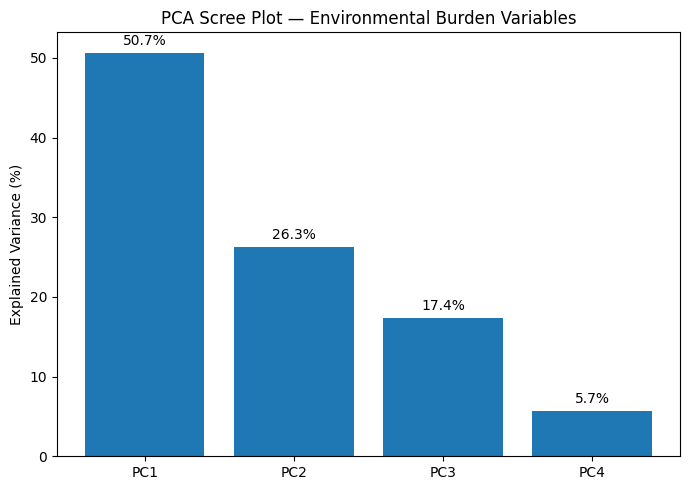

In [23]:
plt.figure(figsize=(7, 5))

components = ["PC1", "PC2", "PC3", "PC4"]
variance_pct = explained_variance * 100

plt.bar(components, variance_pct)

for i, v in enumerate(variance_pct):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.ylabel("Explained Variance (%)")
plt.title("PCA Scree Plot — Environmental Burden Variables")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_pca_scree_plot.png", dpi=150)
plt.show()

In [25]:
#EBS vs IMD correlation
from scipy import stats

In [26]:
rho, p_value = stats.spearmanr(df["ebs"], df["imd_score_mean"])

print(f"Spearman correlation between EBS and IMD score: rho={rho:.3f}, p={p_value:.4f}")

Spearman correlation between EBS and IMD score: rho=0.273, p=0.1242


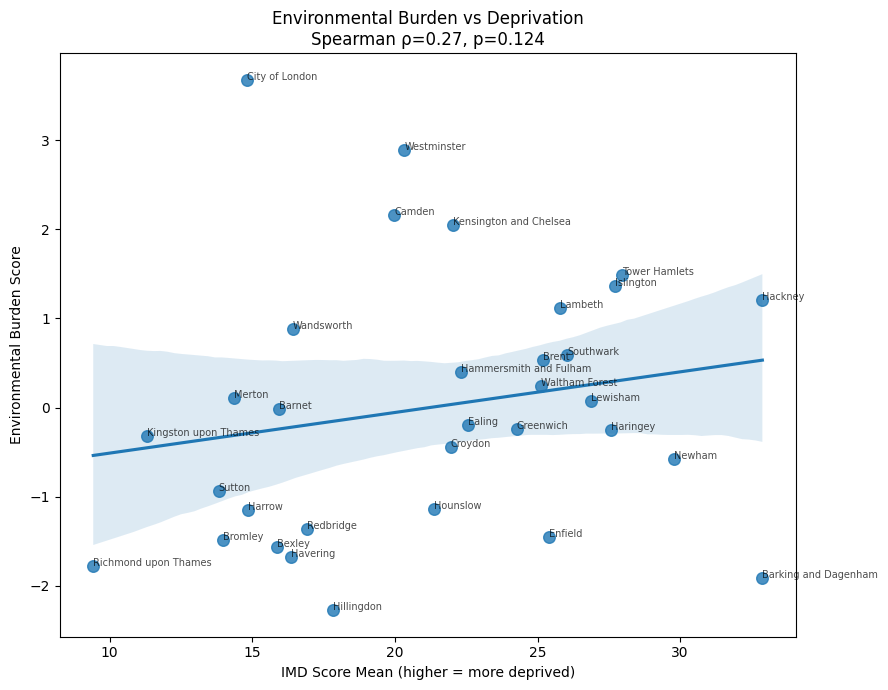

In [27]:
#EBS vs IMD scatter plot
plt.figure(figsize=(9, 7))

sns.regplot(
    data=df,
    x="imd_score_mean",
    y="ebs",
    scatter_kws={"s": 70}
)

for _, row in df.iterrows():
    plt.text(
        row["imd_score_mean"],
        row["ebs"],
        row["borough_name"],
        fontsize=7,
        alpha=0.7
    )

plt.xlabel("IMD Score Mean (higher = more deprived)")
plt.ylabel("Environmental Burden Score")
plt.title(f"Environmental Burden vs Deprivation\nSpearman ρ={rho:.2f}, p={p_value:.3f}")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_ebs_vs_imd.png", dpi=150)
plt.show()

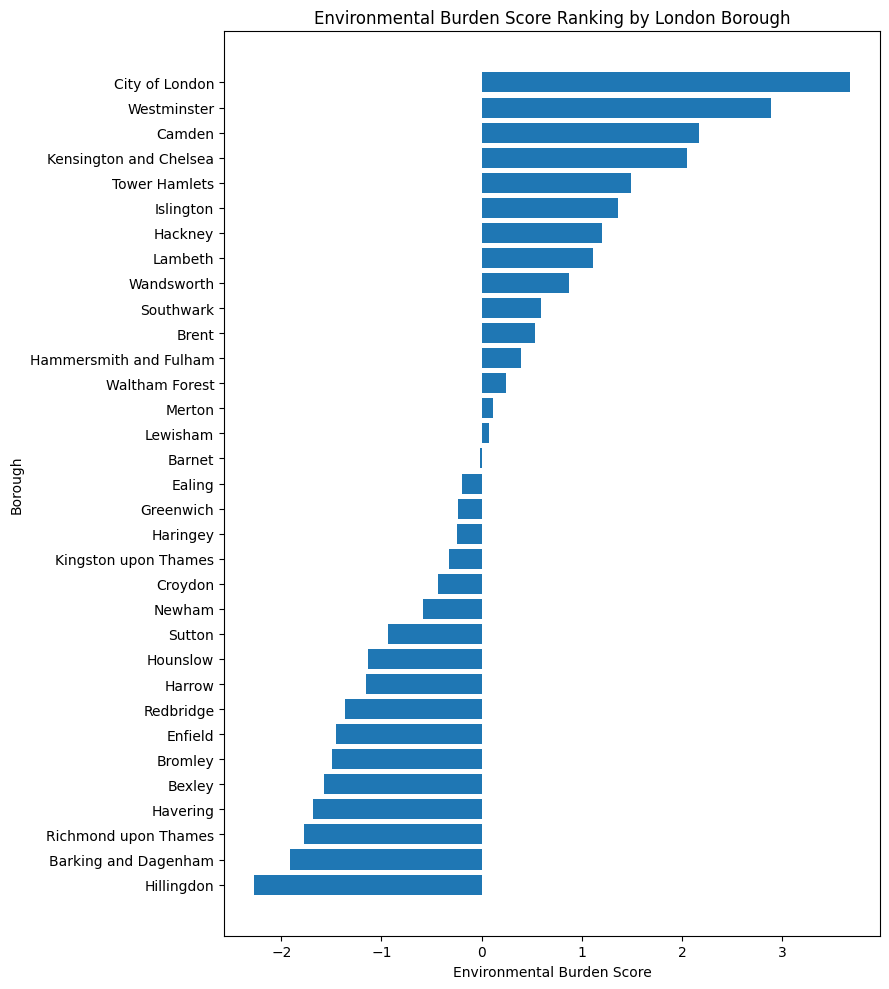

In [28]:
#EBS ranking bar chart
ebs_ranked = df.sort_values("ebs", ascending=True)

plt.figure(figsize=(9, 10))

plt.barh(
    ebs_ranked["borough_name"],
    ebs_ranked["ebs"]
)

plt.xlabel("Environmental Burden Score")
plt.ylabel("Borough")
plt.title("Environmental Burden Score Ranking by London Borough")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_ebs_ranking.png", dpi=150)
plt.show()

In [29]:
#EBS choropleth map
boroughs = gpd.read_file(f"{DATA_DIR}/London_Borough_Excluding_MHW.shp")

boroughs = boroughs[["GSS_CODE", "NAME", "geometry"]].rename(
    columns={
        "GSS_CODE": "borough_code",
        "NAME": "borough_name"
    }
)

boroughs = boroughs.to_crs("EPSG:27700")

In [30]:
ebs_map = boroughs.merge(
    df[["borough_name", "ebs", "ebs_rank"]],
    on="borough_name",
    how="left"
)

ebs_map.isnull().sum()

borough_code    0
borough_name    0
geometry        0
ebs             0
ebs_rank        0
dtype: int64

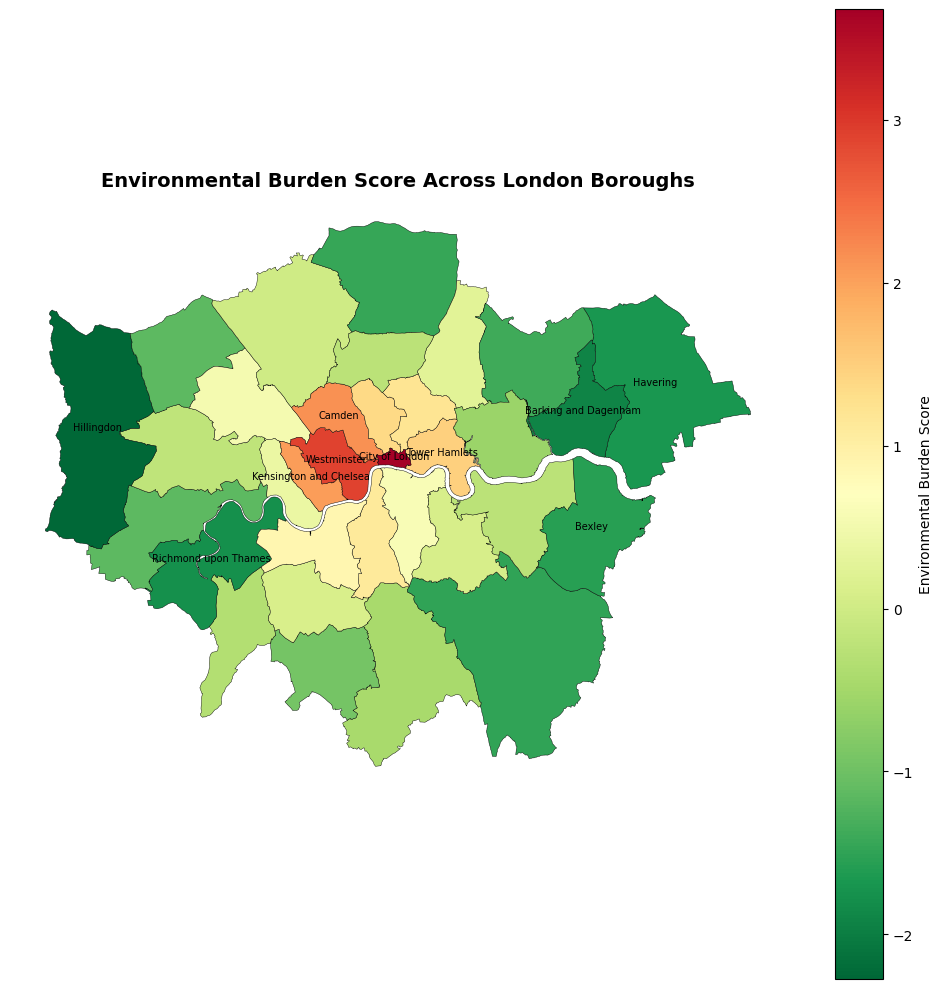

In [31]:
fig, ax = plt.subplots(figsize=(10, 10))

ebs_map.plot(
    column="ebs",
    legend=True,
    ax=ax,
    cmap="RdYlGn_r",
    edgecolor="black",
    linewidth=0.3,
    legend_kwds={
        "label": "Environmental Burden Score",
        "orientation": "vertical"
    }
)

for _, row in ebs_map.iterrows():
    if row["ebs_rank"] <= 5 or row["ebs_rank"] >= 29:
        centroid = row.geometry.centroid
        ax.annotate(
            row["borough_name"],
            xy=(centroid.x, centroid.y),
            fontsize=7,
            ha="center"
        )

ax.set_title(
    "Environmental Burden Score Across London Boroughs",
    fontsize=14,
    fontweight="bold"
)

ax.set_axis_off()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_ebs_choropleth.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
df.to_parquet(f"{DATA_DIR}/ebs_results.parquet")

print(f"Saved PCA/EBS results to: {DATA_DIR}/ebs_results.parquet")

Saved PCA/EBS results to: /Users/yongyili/EnvHealthLondon/data/ebs_results.parquet


In [33]:
job = bq_client.load_table_from_dataframe(
    df,
    BQ_TABLE_EBS,
    job_config=bigquery.LoadJobConfig(
        write_disposition="WRITE_TRUNCATE"
    )
)

job.result()

print(f"Loaded EBS results to BigQuery: {BQ_TABLE_EBS}")

Loaded EBS results to BigQuery: env-health-london-2026.env_health.ebs_results


In [34]:
query = f"""
SELECT borough_name, ebs, ebs_rank, imd_score_mean
FROM `{BQ_TABLE_EBS}`
ORDER BY ebs_rank
LIMIT 10
"""

bq_client.query(query).to_dataframe()

,borough_name,ebs,ebs_rank,imd_score_mean
0,City of London,3.679246,1,14.805000
1,Westminster,2.889434,2,20.331844
2,Camden,2.165696,3,19.981053
3,Kensington and Chelsea,2.045363,4,22.019301
4,Tower Hamlets,1.489546,5,27.970458
5,Islington,1.359833,6,27.706041
6,Hackney,1.201679,7,32.868201
7,Lambeth,1.114035,8,25.797247
8,Wandsworth,0.876502,9,16.420263
9,Southwark,0.595346,10,26.041289


In [35]:
explained_variance.round(3)
#conclusion: #conclusion: The first principal component explained 50.7% of the total variance, indicating that a single composite score captures a substantial shared environmental burden dimension across London boroughs.

array([0.507, 0.263, 0.174, 0.057])

In [36]:
loadings
#conclusion: PC1 loaded most strongly on major road density, Lden noise and NO₂, so it was interpreted as a traffic-related environmental burden dimension. Green-space share loaded weakly on PC1 but strongly on PC2, suggesting that green-space provision forms a distinct environmental axis rather than simply mirroring traffic exposure.

,PC1,PC2,PC3,PC4
no2_baseline_mean,0.482502,-0.211579,0.822437,-0.214530
lden_mean,0.592556,-0.106322,-0.530628,-0.596663
major_road_density_km_per_km2,0.641987,0.163740,-0.142711,0.735307
green_space_share_pct,0.062622,0.957663,0.147192,-0.239362


In [37]:
df[["borough_name", "ebs", "ebs_rank"]].sort_values("ebs_rank").head(10)
#conclusion: The highest EBS scores were concentrated in central and inner London boroughs, including City of London, Westminster, Camden and Kensington and Chelsea. This supports the interpretation of the EBS as an urban-intensity burden score linked to traffic exposure and dense road infrastructure.

,borough_name,ebs,ebs_rank
2,City of London,3.679246,1
18,Westminster,2.889434,2
1,Camden,2.165696,3
26,Kensington and Chelsea,2.045363,4
15,Tower Hamlets,1.489546,5
23,Islington,1.359833,6
28,Hackney,1.201679,7
6,Lambeth,1.114035,8
10,Wandsworth,0.876502,9
21,Southwark,0.595346,10


In [38]:
print(f"Spearman correlation between EBS and IMD score: rho={rho:.3f}, p={p_value:.4f}")

Spearman correlation between EBS and IMD score: rho=0.273, p=0.1242


In [ ]:
#conclusion: The EBS showed a positive association with IMD deprivation score, but the relationship was not statistically significant at the 5% level. This suggests that environmental burden may be partly related to deprivation, but the pattern is not strong enough at borough level to support a definitive inequality claim.

In [ ]:
#Result:
#“Environmental burden is spatially concentrated in central and inner London. It shows a positive but statistically non-significant association with deprivation, suggesting that borough-level environmental inequality is present but complex and not fully explained by IMD alone.”